In [1]:
# Necessary imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torchvision import transforms
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [ ]:
# This dataset class allows easy loading of Zellige images for training a machine learning model.
class ZelligeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.true_dir = os.path.join(root_dir, 'true')
        self.false_dir = os.path.join(root_dir, 'false')

        self.image_paths = []
        self.labels = []

        # Load images with labels (0 or 1)
        # Ensure directories exist before listing files
        if os.path.exists(self.true_dir):
            for img_name in os.listdir(self.true_dir):
                self.image_paths.append(os.path.join(self.true_dir, img_name))
                self.labels.append(1)
        else:
            print(f"Warning: Directory not found: {self.true_dir}")

        if os.path.exists(self.false_dir):
            for img_name in os.listdir(self.false_dir):
                self.image_paths.append(os.path.join(self.false_dir, img_name))
                self.labels.append(0)
        else:
            print(f"Warning: Directory not found: {self.false_dir}")

    def __len__(self):
        return len(self.image_paths)

    def rescale_image(self, image):
        # image = image / 255.0 # Example basic scaling 
        return image.astype(np.float32) # Ensure float type for transforms


    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        try:
            image = cv2.imread(img_path)
            if image is None:
                print(f"Warning: Failed to load image {img_path}. Skipping.")
                # Return a dummy image and label or handle differently
                return torch.zeros(3, 64, 64), torch.tensor(-1.0, dtype=torch.float32) # Example dummy data

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = self.rescale_image(image) # Apply potential custom rescaling

            if self.transform:
                # Assuming the transform includes ToTensor() which converts HWC uint8 to CHW float tensor
                image = self.transform(image)

            return image, torch.tensor(label, dtype=torch.float32) #return the result

        except Exception as e:
            print(f"Error processing image {img_path}: {e}")
             # Return dummy data on error
            return torch.zeros(3, 64, 64), torch.tensor(-1.0, dtype=torch.float32)

In [ ]:
# Transforms
train_transform = transforms.Compose([
    transforms.ToPILImage(), # Convert numpy array to PIL Image first for torchvision transforms
    transforms.Resize((128, 128)), # Example resize, adjust as needed
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(), # Converts PIL image to PyTorch tensor (normalizes pixel values to [0,1])
])

val_test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 128)), # Ensure consistent size
    transforms.ToTensor(),
])

In [ ]:
# Dataset Paths
# !!! IMPORTANT: Verify this path exists and is correct for your environment !!!
base_path = '/kaggle/input/moroccan-zellige/moroccan-zellige' # Verify your path!

# Check if base path exists
if not os.path.exists(base_path):
    print(f"Error: Base path '{base_path}' does not exist. Please check the path.")
    # Depending on the environment, you might stop execution here or proceed with warnings.
    # raise FileNotFoundError(f"Base path '{base_path}' not found.")

train_dataset = ZelligeDataset( #Loads training images
    os.path.join(base_path, 'train'),
    transform=train_transform
)

val_dataset = ZelligeDataset(   #Loads validation images
    os.path.join(base_path, 'validation'),
    transform=val_test_transform
)

test_dataset = ZelligeDataset(  #Loads testing images
    os.path.join(base_path, 'test'),
    transform=val_test_transform
)

#  DataLoaders 
# Filter out samples that failed to load (where label is -1)
def collate_fn(batch):
    batch = list(filter(lambda x: x[1] != -1.0, batch))
    if not batch:  # If all samples in the batch failed
        return torch.empty(0), torch.empty(0)
    return torch.utils.data.dataloader.default_collate(batch)


# Check if datasets are empty before creating DataLoaders
if len(train_dataset) > 0:
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn) #shuffle are necessary in while training
    print(f"Train loader created with {len(train_dataset)} samples.")
else:
    print("Warning: Training dataset is empty. Train loader not created.")
    train_loader = None # Or handle as an error

if len(val_dataset) > 0:
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn) # Usually no shuffle for validation
    print(f"Validation loader created with {len(val_dataset)} samples.")
else:
    print("Warning: Validation dataset is empty. Validation loader not created.")
    val_loader = None

if len(test_dataset) > 0:
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn) # Usually no shuffle for test
    print(f"Test loader created with {len(test_dataset)} samples.")
else:
    print("Warning: Test dataset is empty. Test loader not created.")
    test_loader = None


Train loader created with 1102 samples.
Validation loader created with 229 samples.
Test loader created with 229 samples.


In [ ]:
#Unet architecture
class UNetClassifier(nn.Module):
    def __init__(self):
        super(UNetClassifier, self).__init__()

        # Encoder
        self.enc1 = self.conv_block(3, 64)      # First convolutional block (input: 3 channels, output: 64)
        self.enc2 = self.conv_block(64, 128)     # Second convolutional block (input: 64, output: 128)
        self.enc3 = self.conv_block(128, 256)    # Third convolutional block (input: 128, output: 256)

        # Decoder
        self.dec3 = self.upconv_block(256, 128)  # Upsample from 256 to 128 channels
        self.dec2 = self.upconv_block(128, 64)   # Upsample from 128 to 64 channels

        # Classification/prediction layer
        self.final = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), 
            nn.Flatten(),
            nn.Linear(64, 1)         # Output 1 logit for binary classification #Pytorch function 
        )
    # Convolutional block with Conv2D, ReLU activation, and MaxPooling
    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), # Added BatchNorm
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), # Added second conv layer
            nn.BatchNorm2d(out_ch), # Added BatchNorm
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

    # Transposed convolutional block for upsampling
    def upconv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2),
            nn.ReLU(inplace=True)
        )

    # The Forward Function
    def forward(self, x):
        # Encoder path
        x1 = self.enc1(x)  # Pass input through first encoder block
        x2 = self.enc2(x1) # Pass through second encoder block
        x3 = self.enc3(x2) # Pass through third encoder block
      
        d3 = self.dec3(x3) # Upsample from 256 to 128 channels
        d2 = self.dec2(d3) # Upsample from 128 to 64 channels

        # Final classification layer
        output_logits = self.final(d2)
        return output_logits # Returns raw logits

In [ ]:
# Select the device (GPU if available, otherwise CPU)
# It is recommended to use a strong GPU; the one used in the original model was P100 (available in Kaggle)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = UNetClassifier().to(device) # Initialize the U-Net classifier and move it to the selected device(GPU/CPU)

# Handle class imbalance (only if train_dataset loaded successfully)
if train_loader and len(train_dataset.labels) > 0:
    # Calculate weights based on loaded labels, excluding error (-1) labels
    true_labels_count = sum(1 for label in train_dataset.labels if label == 1) #zellige images 
    false_labels_count = sum(1 for label in train_dataset.labels if label == 0) #non-zellige images 

    if true_labels_count > 0 and false_labels_count > 0:
        pos_weight_val = false_labels_count / true_labels_count
        pos_weight = torch.tensor([pos_weight_val], device=device) # Move tensor to device
        print(f"Calculated positive weight for BCEWithLogitsLoss: {pos_weight.item():.4f}")
    else:
        print("Warning: Could not calculate positive weight due to missing classes in training data. Using default weight.")
        pos_weight = None # Use default weights if one class is missing
else:
    print("Warning: Train loader not available or dataset empty. Using default weight for loss.")
    pos_weight = None

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # Pass the calculated weight tensor (or None)

# The optimizer (Adam) with a learning rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning Rate Scheduler (Optional but often helpful)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1) # Example: Reduce LR every 30 epochs 

Using device: cuda
Calculated positive weight for BCEWithLogitsLoss: 0.5811


In [ ]:
# Training and validation metrics storage
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Recomanded : number of epochs = 100 more or less 
num_epochs = 100

# Check if loaders exist before starting training
if not train_loader:
    print("Error: Train loader is not initialized. Cannot start training.")
elif not val_loader:
    print("Warning: Validation loader is not initialized. Validation steps will be skipped.")
else:
    print(f"Starting training for {num_epochs} epochs...")
    # Training process
    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        running_train_loss = 0.0
        TP_train, TN_train, FP_train, FN_train = 0, 0, 0, 0

        for inputs, labels in train_loader:
            # Ensure labels are in the correct shape [batch_size, 1] for BCEWithLogitsLoss
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs) # Model outputs raw logits
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * inputs.size(0) # Weighted average loss

            # Calculate accuracy and confusion matrix components for the batch 
            preds_prob = torch.sigmoid(outputs)
            preds = (preds_prob > 0.5).float() # Threshold probabilities to get binary predictions (0 or 1)

            # Ensure labels are also float for comparison if needed, or keep preds as long
            labels_squeezed = labels.squeeze().long() # Squeeze labels back for comparison if needed
            preds_squeezed = preds.squeeze().long()

            # Calculate confusion matrix components for the batch
            TP = ((preds == 1) & (labels == 1)).sum().item()
            TN = ((preds == 0) & (labels == 0)).sum().item()
            FP = ((preds == 1) & (labels == 0)).sum().item()
            FN = ((preds == 0) & (labels == 1)).sum().item()

            TP_train += TP
            TN_train += TN
            FP_train += FP
            FN_train += FN
            # total_train_samples += labels.size(0)


        # --- Epoch End Calculation (Training) ---
        epoch_train_loss = running_train_loss / len(train_loader.dataset) # Average loss per sample
        total_train_preds = TP_train + TN_train + FP_train + FN_train
        epoch_train_acc = (TP_train + TN_train) / total_train_preds if total_train_preds > 0 else 0.0

        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)

        # --- Validation loop ---
        epoch_val_loss = 0.0
        epoch_val_acc = 0.0
        if val_loader: # Only run validation if val_loader exists
            model.eval() # Set model to evaluation mode
            running_val_loss = 0.0
            TP_val, TN_val, FP_val, FN_val = 0, 0, 0, 0
            # total_val_samples = 0

            with torch.no_grad(): # No gradients needed for validation
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()

                    outputs = model(inputs) # Get logits
                    val_loss = criterion(outputs, labels) # Calculate loss
                    running_val_loss += val_loss.item() * inputs.size(0)

                    # *** SIGMOID function used here to convert logits to probabilities for prediction ***
                    preds_prob = torch.sigmoid(outputs)
                    preds = (preds_prob > 0.5).float() # Threshold

                    labels_squeezed = labels.squeeze().long()
                    preds_squeezed = preds.squeeze().long()

                    # Accumulate validation confusion matrix components
                    TP_val += ((preds == 1) & (labels == 1)).sum().item()
                    TN_val += ((preds == 0) & (labels == 0)).sum().item()
                    FP_val += ((preds == 1) & (labels == 0)).sum().item()
                    FN_val += ((preds == 0) & (labels == 1)).sum().item()
                    # total_val_samples += labels.size(0)

            # --- Epoch End Calculation (Validation) ---
            epoch_val_loss = running_val_loss / len(val_loader.dataset)
            total_val_preds = TP_val + TN_val + FP_val + FN_val
            epoch_val_acc = (TP_val + TN_val) / total_val_preds if total_val_preds > 0 else 0.0

            val_losses.append(epoch_val_loss)
            val_accuracies.append(epoch_val_acc)

            # Print Epoch Results
            print(f"Epoch {epoch+1}/{num_epochs}")
            print(f"  Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
            print(f"  Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}\n")

        else: # Handle case where there is no validation loader
             val_losses.append(None) # Append None or 0 if no validation
             val_accuracies.append(None)
             print(f"Epoch {epoch+1}/{num_epochs}")
             print(f"  Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
             print(f"  Validation skipped (no validation data).\n")

    print("Training finished.")

Starting training for 100 epochs...
Epoch 1/100
  Train Loss: 0.4638 | Train Acc: 0.6887
  Val Loss:   0.4615 | Val Acc:   0.5546

Epoch 2/100
  Train Loss: 0.3922 | Train Acc: 0.7377
  Val Loss:   0.4547 | Val Acc:   0.5633

Epoch 3/100
  Train Loss: 0.3733 | Train Acc: 0.7813
  Val Loss:   0.3933 | Val Acc:   0.6987

Epoch 4/100
  Train Loss: 0.3430 | Train Acc: 0.7849
  Val Loss:   0.3093 | Val Acc:   0.7511

Epoch 5/100
  Train Loss: 0.3059 | Train Acc: 0.8031
  Val Loss:   0.3452 | Val Acc:   0.8166

Epoch 6/100
  Train Loss: 0.2961 | Train Acc: 0.8348
  Val Loss:   0.2520 | Val Acc:   0.8297

Epoch 7/100
  Train Loss: 0.2617 | Train Acc: 0.8503
  Val Loss:   0.2863 | Val Acc:   0.8515

Epoch 8/100
  Train Loss: 0.2521 | Train Acc: 0.8512
  Val Loss:   0.2022 | Val Acc:   0.8690

Epoch 9/100
  Train Loss: 0.2290 | Train Acc: 0.8693
  Val Loss:   0.3514 | Val Acc:   0.7380

Epoch 10/100
  Train Loss: 0.2540 | Train Acc: 0.8494
  Val Loss:   0.3855 | Val Acc:   0.6900

Epoch 11/100


In [ ]:
# Evaluate final model on TEST data for confusion matrix

final_TP_test, final_TN_test, final_FP_test, final_FN_test = 0, 0, 0, 0
all_test_labels = []
all_test_preds = []

# Check if test_loader exists before evaluating
if test_loader:
    print("\nEvaluating final model on the Test Set...")
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Turn off gradients for evaluation
        for inputs, labels in test_loader:
            # Ensure data is on the correct device and labels have the right shape
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()

            # Get model predictions (logits)
            outputs = model(inputs)

            # *** SIGMOID function used here to convert logits to probabilities for prediction ***
            preds_prob = torch.sigmoid(outputs)
            preds = (preds_prob > 0.5).float() # Threshold probabilities to get binary predictions (0 or 1)

            # Store labels and predictions for detailed report (optional)
            all_test_labels.extend(labels.squeeze().cpu().numpy())
            all_test_preds.extend(preds.squeeze().cpu().numpy())

            # Accumulate final test set confusion matrix components
            final_TP_test += ((preds == 1) & (labels == 1)).sum().item()
            final_TN_test += ((preds == 0) & (labels == 0)).sum().item()
            final_FP_test += ((preds == 1) & (labels == 0)).sum().item()
            final_FN_test += ((preds == 0) & (labels == 1)).sum().item()

    print("Finished evaluating on the Test Set.")
    print(f"  Final Test TP: {final_TP_test}, TN: {final_TN_test}, FP: {final_FP_test}, FN: {final_FN_test}")

    # Optional: Print classification report for the test set
    from sklearn.metrics import classification_report
    print("\nTest Set Classification Report:")
    if all_test_labels and all_test_preds:
        try:
            print(classification_report(all_test_labels, all_test_preds, target_names=['Non-Zellige (0)', 'Zellige (1)'], zero_division=0))
        except ValueError as e:
            print(f"Could not generate classification report: {e}") # Handle cases with only one class predicted/present
    else:
        print("Could not generate classification report (no labels/preds gathered).")

else:
    print("Test loader not available. Cannot evaluate on the test set.")


Evaluating final model on the Test Set...
Finished evaluating on the Test Set.
  Final Test TP: 133, TN: 79, FP: 7, FN: 10

Test Set Classification Report:
                 precision    recall  f1-score   support

Non-Zellige (0)       0.89      0.92      0.90        86
    Zellige (1)       0.95      0.93      0.94       143

       accuracy                           0.93       229
      macro avg       0.92      0.92      0.92       229
   weighted avg       0.93      0.93      0.93       229



Confusion matrix saved to confusion_matrix_test.png
Metrics plot saved to metrics_test.png


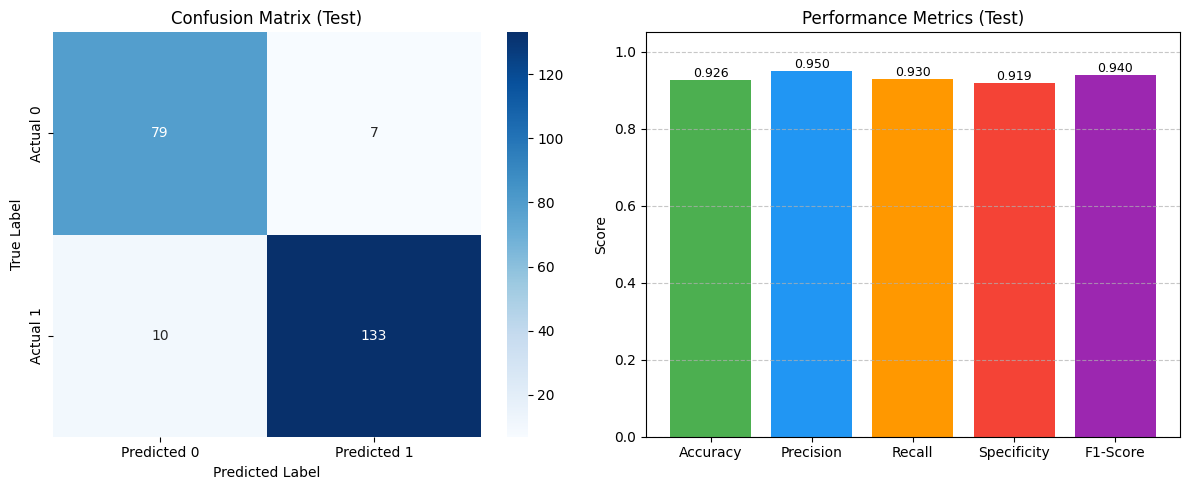

In [14]:
# Function to visualize Accuracy / Confusion Matrix Data (Definition remains the same)
def plot_confusion_metrics(TP, FP, TN, FN, mode='validation', save_path_cm=None, save_path_metrics=None):

    total = TP + TN + FP + FN
    if total == 0:
        print(f"Cannot plot metrics for '{mode}' - No data points.")
        return

    plt.figure(figsize=(12, 5))

    # Calculate metrics
    accuracy = (TP + TN) / total
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0 # Also known as Sensitivity
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    # --- Subplot 1: Confusion Matrix ---
    plt.subplot(1, 2, 1)
    conf_matrix = [[TN, FP], [FN, TP]] # Standard layout: TN, FP, FN, TP
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix ({mode.capitalize()})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    if save_path_cm:
        plt.savefig(save_path_cm, bbox_inches='tight')
        print(f"Confusion matrix saved to {save_path_cm}")


    # --- Subplot 2: Performance Metrics Bar Chart ---
    plt.subplot(1, 2, 2)
    metrics_dict = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1-Score': f1
    }
    metrics_names = list(metrics_dict.keys())
    metrics_values = list(metrics_dict.values())

    # Define colors for bars (adjust as desired)
    colors = ['#4CAF50', '#2196F3', '#FF9800', '#f44336', '#9C27B0'] # Green, Blue, Orange, Red, Purple

    bars = plt.bar(metrics_names, metrics_values, color=colors[:len(metrics_names)])
    plt.title(f'Performance Metrics ({mode.capitalize()})')
    plt.ylim(0, 1.05) # Extend y-limit slightly
    plt.ylabel('Score')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add text labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', # Show 3 decimal places
                 ha='center', va='bottom', fontsize=9)

    if save_path_metrics:
         plt.savefig(save_path_metrics, bbox_inches='tight')
         print(f"Metrics plot saved to {save_path_metrics}")

    plt.tight_layout() # Adjust layout to prevent overlap
    plt.show()


# *** CHANGE: Call the function with the final TEST metrics ***
if test_loader: # Only plot if evaluation on test set was done
    plot_confusion_metrics(
        final_TP_test,       # Use test TP
        final_FP_test,       # Use test FP
        final_TN_test,       # Use test TN
        final_FN_test,       # Use test FN
        mode='test',         # Specify mode as 'test'
        save_path_cm='confusion_matrix_test.png',    # Update save path
        save_path_metrics='metrics_test.png'         # Update save path
    )
else:
    print("Cannot plot confusion matrix for test set (no evaluation data).")


Sample Predictions vs Reality (Test Set):


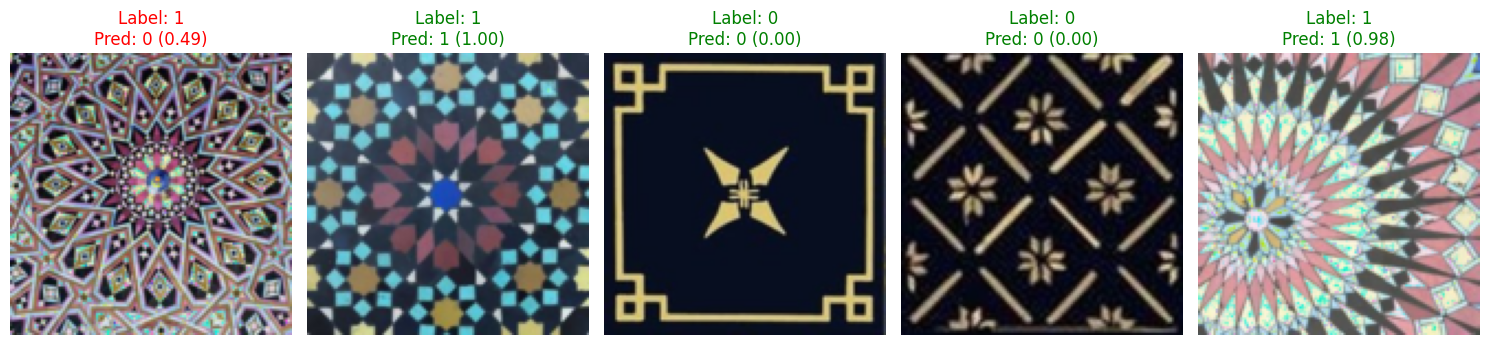

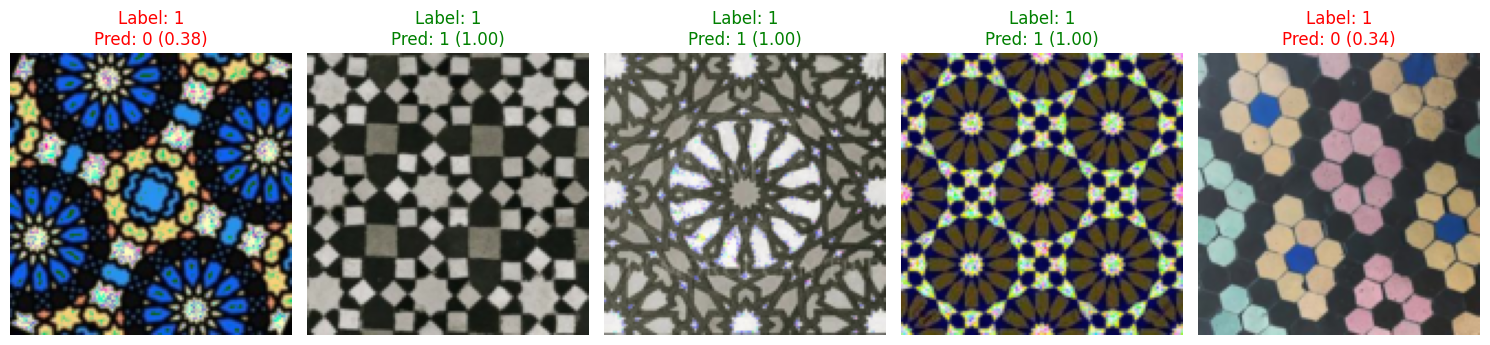

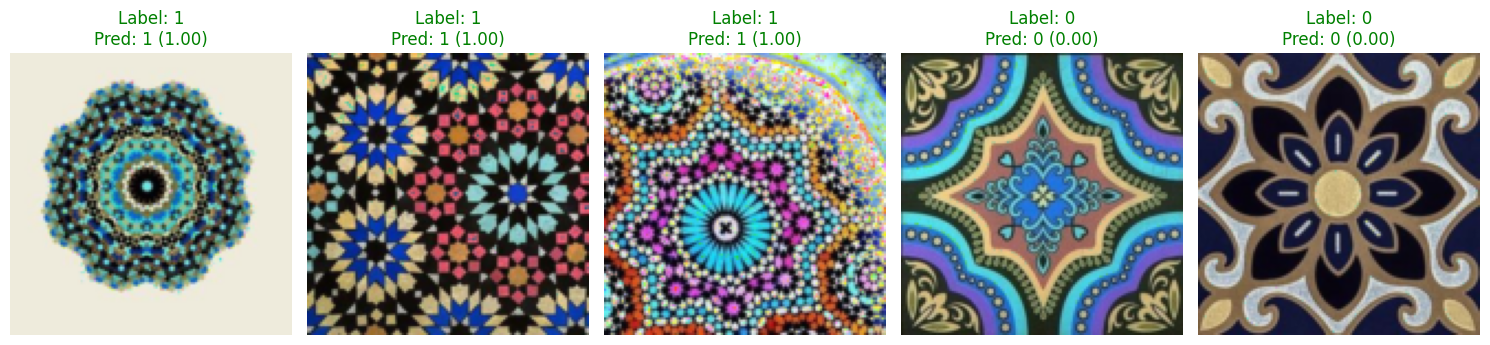

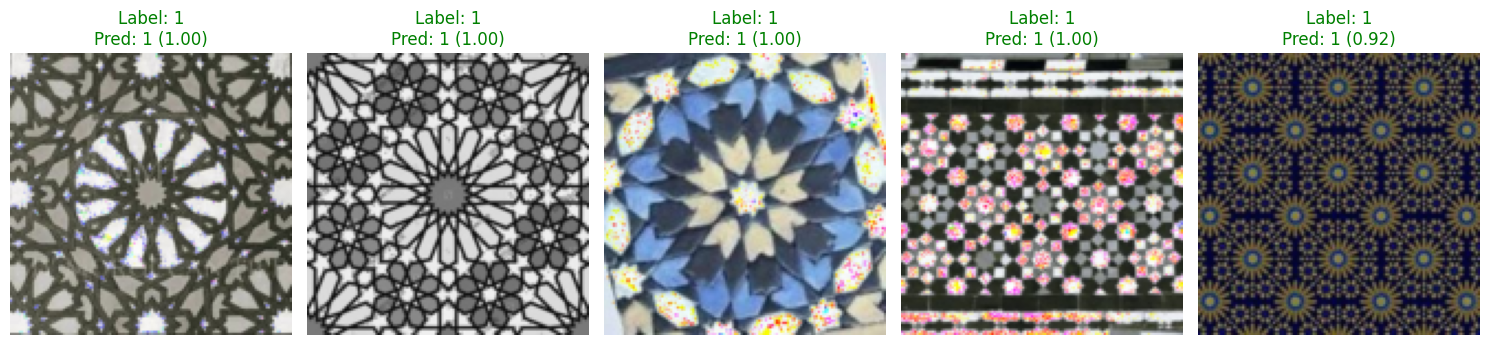

In [20]:
# Function for visualization of: prediction vs reality
def visualize_results(dataset, model, device, num_samples=5):
    if not dataset or len(dataset) == 0:
        print("Cannot visualize results: Dataset is empty or not provided.")
        return
    if num_samples > len(dataset):
        print(f"Warning: Requested {num_samples} samples, but dataset only has {len(dataset)}. Visualizing {len(dataset)} samples.")
        num_samples = len(dataset)
    if num_samples == 0:
        print("Cannot visualize results: Number of samples is zero.")
        return


    plt.figure(figsize=(15, 5)) # Adjusted figure size for single row
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)

    model.eval() # Ensure model is in eval mode

    for i, idx in enumerate(indices):
        try:
            image, label = dataset[idx]

            # Handle potential loading errors from dataset
            if isinstance(image, torch.Tensor) and image.nelement() == 0:
                 print(f"Skipping visualization for index {idx} due to loading error.")
                 continue

            image_tensor = image.unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(image_tensor)
                # *** SIGMOID function used here to convert logits to probability ***
                pred_prob = torch.sigmoid(output).item()
                prediction = int(pred_prob > 0.5) # Get binary prediction (0 or 1)

            # Convert tensor back to numpy array for display (CHW -> HWC)
            # Denormalize if necessary (assuming [0, 1] range from ToTensor)
            img_np = image.cpu().numpy().transpose(1, 2, 0)
            if img_np.min() >= 0 and img_np.max() <= 1:
                 img_np = (img_np * 255).astype(np.uint8)
            else:
                 img_np = np.clip(img_np, 0, 255).astype(np.uint8)


            true_label_val = int(label.item()) # Get scalar value from tensor
            # Determine title color based on correctness
            color = 'green' if prediction == true_label_val else 'red'

            # Plotting
            plt.subplot(1, num_samples, i + 1) # Single row of plots
            plt.imshow(img_np)
            # *** CHANGE: Use "Label:" instead of "True:" ***
            plt.title(f"Label: {true_label_val}\nPred: {prediction} ({pred_prob:.2f})", color=color)
            plt.axis('off')

        except Exception as e:
             print(f"Error visualizing sample at index {idx}: {e}")
             plt.subplot(1, num_samples, i + 1)
             plt.title(f"Error loading\nIndex: {idx}")
             plt.axis('off')

    plt.tight_layout()
    plt.show()


# --- Show test results ---
if test_loader: # Check if test_loader exists
    print("\nSample Predictions vs Reality (Test Set):")
    # Calling it multiple times shows different random samples
    visualize_results(test_dataset, model, device, num_samples=5)
    visualize_results(test_dataset, model, device, num_samples=5)
    visualize_results(test_dataset, model, device, num_samples=5)
    visualize_results(test_dataset, model, device, num_samples=5)
    # visualize_results(test_dataset, model, device, num_samples=3) # Original calls
else:
    print("Test loader not available. Cannot visualize results on test set.")